In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

import re 
import string 

from sklearn.model_selection import train_test_split 

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC 
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score ,precision_score, recall_score ,f1_score,confusion_matrix,classification_report

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
import streamlit as st

In [2]:
df=pd.read_csv('emails.csv')

In [3]:
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 8.6 MB


In [5]:
df['spam'].value_counts()

spam
0    4360
1    1368
Name: count, dtype: int64

In [6]:
df['text'][0]

"Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowadays market ; but we do promise that your marketing efforts  will become much more effective . here is the list of clear  benefits : creativeness : hand - made , original logos , specially done  to reflect your distinctive company image . convenience : logo and stationery  are provided in all formats ; easy - to - use content management system letsyou  change your website content and even its structure . promptness : you  will see logo drafts within three business days . affordability : your  ma

In [7]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words =set(stopwords.words('english'))
stop_words

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [8]:
df['text'][0].split()

['Subject:',
 'naturally',
 'irresistible',
 'your',
 'corporate',
 'identity',
 'lt',
 'is',
 'really',
 'hard',
 'to',
 'recollect',
 'a',
 'company',
 ':',
 'the',
 'market',
 'is',
 'full',
 'of',
 'suqgestions',
 'and',
 'the',
 'information',
 'isoverwhelminq',
 ';',
 'but',
 'a',
 'good',
 'catchy',
 'logo',
 ',',
 'stylish',
 'statlonery',
 'and',
 'outstanding',
 'website',
 'will',
 'make',
 'the',
 'task',
 'much',
 'easier',
 '.',
 'we',
 'do',
 'not',
 'promise',
 'that',
 'havinq',
 'ordered',
 'a',
 'iogo',
 'your',
 'company',
 'will',
 'automaticaily',
 'become',
 'a',
 'world',
 'ieader',
 ':',
 'it',
 'isguite',
 'ciear',
 'that',
 'without',
 'good',
 'products',
 ',',
 'effective',
 'business',
 'organization',
 'and',
 'practicable',
 'aim',
 'it',
 'will',
 'be',
 'hotat',
 'nowadays',
 'market',
 ';',
 'but',
 'we',
 'do',
 'promise',
 'that',
 'your',
 'marketing',
 'efforts',
 'will',
 'become',
 'much',
 'more',
 'effective',
 '.',
 'here',
 'is',
 'the',
 'l

In [9]:
words =[word for word in df['text'][0].split() if word not in stop_words]
" " .join(words)

"Subject: naturally irresistible corporate identity lt really hard recollect company : market full suqgestions information isoverwhelminq ; good catchy logo , stylish statlonery outstanding website make task much easier . promise havinq ordered iogo company automaticaily become world ieader : isguite ciear without good products , effective business organization practicable aim hotat nowadays market ; promise marketing efforts become much effective . list clear benefits : creativeness : hand - made , original logos , specially done reflect distinctive company image . convenience : logo stationery provided formats ; easy - - use content management system letsyou change website content even structure . promptness : see logo drafts within three business days . affordability : marketing break - ' make gaps budget . 100 % satisfaction guaranteed : provide unlimited amount changes extra fees surethat love result collaboration . look portfolio _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ 

In [10]:

def remove_stop_words(text):
    words =text.split()
    words =[word for word in words if word  not in stop_words]
    return  " ".join(words)
df['new_text'] = df['text'].apply(remove_stop_words)
df['new_text']

0       Subject: naturally irresistible corporate iden...
1       Subject: stock trading gunslinger fanny merril...
2       Subject: unbelievable new homes made easy im w...
3       Subject: 4 color printing special request addi...
4       Subject: money , get software cds ! software c...
                              ...                        
5723    Subject: : research development charges gpg ! ...
5724    Subject: : receipts visit jim , thanks invitat...
5725    Subject: : enron case study update wow ! day ....
5726    Subject: : interest david , please , call shir...
5727    Subject: news : aurora 5 . 2 update aurora ver...
Name: new_text, Length: 5728, dtype: str

In [11]:
df[df['spam']==1]['new_text'].head()

0    Subject: naturally irresistible corporate iden...
1    Subject: stock trading gunslinger fanny merril...
2    Subject: unbelievable new homes made easy im w...
3    Subject: 4 color printing special request addi...
4    Subject: money , get software cds ! software c...
Name: new_text, dtype: str

In [12]:
spam_words=" ".join(df[df['spam']==1]['new_text']).lower().split()
ham_words=" ".join(df[df['spam']==0]['new_text']).lower().split()

In [13]:
from collections import Counter
spam_counter=Counter(spam_words)
ham_counter=Counter(ham_words)

spam_counter.most_common(100)


[('.', 19839),
 ('_', 13556),
 (',', 11514),
 ('-', 8514),
 (':', 4691),
 ('!', 3310),
 ('/', 2578),
 ("'", 2326),
 ('$', 2242),
 ('"', 1655),
 (')', 1598),
 ('(', 1514),
 ('subject:', 1368),
 ('*', 1300),
 ('=', 1182),
 ('com', 998),
 ('?', 981),
 ('1', 952),
 ('business', 844),
 ('company', 805),
 ('email', 804),
 ('|', 789),
 ('information', 740),
 ('e', 698),
 ('5', 687),
 ('money', 662),
 ('%', 659),
 ('2', 613),
 ('free', 606),
 ('3', 604),
 ('http', 600),
 ('get', 590),
 (';', 588),
 ('mail', 586),
 ('one', 581),
 ('please', 581),
 ('@', 575),
 ('000', 560),
 ('us', 537),
 ('click', 531),
 ('time', 521),
 ('new', 504),
 ('make', 496),
 ('may', 489),
 ('website', 465),
 ('adobe', 462),
 ('0', 450),
 ('software', 438),
 ('www', 426),
 ('#', 426),
 ('message', 418),
 ('10', 405),
 ('list', 392),
 ('report', 391),
 ('2005', 374),
 ('want', 364),
 ('account', 363),
 ('4', 358),
 ('best', 357),
 ('like', 352),
 ('people', 348),
 ('within', 346),
 ('order', 345),
 ('online', 345),
 ('a

In [14]:
ham_counter.most_common(100)


[('-', 96708),
 ('.', 72655),
 (',', 49629),
 ('/', 37733),
 (':', 37679),
 ('>', 21997),
 ('@', 13976),
 ('enron', 13382),
 ('ect', 11417),
 (')', 8988),
 ('vince', 8531),
 ("'", 8483),
 ('?', 8446),
 ('(', 8264),
 ('"', 7275),
 ('*', 6490),
 ('hou', 5569),
 ('2000', 4935),
 ('kaminski', 4770),
 ('com', 4444),
 ('please', 4386),
 ('subject:', 4360),
 ('subject', 4245),
 ('would', 4151),
 ('cc', 3889),
 ('j', 3693),
 ('_', 3678),
 ('pm', 3262),
 ('2001', 3060),
 ('research', 2670),
 ('thanks', 2523),
 ('1', 2490),
 ('2', 2323),
 ('know', 2297),
 ('group', 2255),
 ('10', 2213),
 ('time', 2212),
 ('energy', 2115),
 ('=', 2067),
 ('risk', 1984),
 ('may', 1974),
 ('power', 1916),
 (';', 1914),
 ('!', 1865),
 ('3', 1838),
 ('let', 1822),
 ('like', 1795),
 ('new', 1776),
 ('meeting', 1772),
 ('00', 1680),
 ('shirley', 1679),
 ('01', 1673),
 ('11', 1661),
 ('corp', 1643),
 ('edu', 1620),
 ('also', 1604),
 ('houston', 1577),
 ('$', 1572),
 ('e', 1558),
 ('information', 1554),
 ('30', 1538),
 (

In [15]:
df['new_text']= df['text'].apply(
    lambda x:re.sub(r'[^a-zA-Z0-9 ]','',x)
)

In [16]:

print (df['text'][0])
print (df['new_text'][0])

Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowadays market ; but we do promise that your marketing efforts  will become much more effective . here is the list of clear  benefits : creativeness : hand - made , original logos , specially done  to reflect your distinctive company image . convenience : logo and stationery  are provided in all formats ; easy - to - use content management system letsyou  change your website content and even its structure . promptness : you  will see logo drafts within three business days . affordability : your  mar

In [17]:
spam_message= df[df['spam']==1]
spam_message

,text,spam,new_text
0,Subject: naturally irresistible your corporate...,1,Subject naturally irresistible your corporate ...
1,Subject: the stock trading gunslinger fanny i...,1,Subject the stock trading gunslinger fanny is...
2,Subject: unbelievable new homes made easy im ...,1,Subject unbelievable new homes made easy im w...
3,Subject: 4 color printing special request add...,1,Subject 4 color printing special request addi...
4,"Subject: do not have money , get software cds ...",1,Subject do not have money get software cds fr...
...,...,...,...
1363,Subject: are you ready to get it ? hello ! v...,1,Subject are you ready to get it hello viag...
1364,Subject: would you like a $ 250 gas card ? do...,1,Subject would you like a 250 gas card don ...
1365,"Subject: immediate reply needed dear sir , i...",1,Subject immediate reply needed dear sir i a...
1366,Subject: wanna see me get fisted ? fist bang...,1,Subject wanna see me get fisted fist bang w...


In [18]:
spam_text=' '.join(spam_message['new_text'])
spam_text
words=spam_text.split()
words

['Subject',
 'naturally',
 'irresistible',
 'your',
 'corporate',
 'identity',
 'lt',
 'is',
 'really',
 'hard',
 'to',
 'recollect',
 'a',
 'company',
 'the',
 'market',
 'is',
 'full',
 'of',
 'suqgestions',
 'and',
 'the',
 'information',
 'isoverwhelminq',
 'but',
 'a',
 'good',
 'catchy',
 'logo',
 'stylish',
 'statlonery',
 'and',
 'outstanding',
 'website',
 'will',
 'make',
 'the',
 'task',
 'much',
 'easier',
 'we',
 'do',
 'not',
 'promise',
 'that',
 'havinq',
 'ordered',
 'a',
 'iogo',
 'your',
 'company',
 'will',
 'automaticaily',
 'become',
 'a',
 'world',
 'ieader',
 'it',
 'isguite',
 'ciear',
 'that',
 'without',
 'good',
 'products',
 'effective',
 'business',
 'organization',
 'and',
 'practicable',
 'aim',
 'it',
 'will',
 'be',
 'hotat',
 'nowadays',
 'market',
 'but',
 'we',
 'do',
 'promise',
 'that',
 'your',
 'marketing',
 'efforts',
 'will',
 'become',
 'much',
 'more',
 'effective',
 'here',
 'is',
 'the',
 'list',
 'of',
 'clear',
 'benefits',
 'creativenes

In [19]:
ham_message=df[df['spam']==0]
ham_message

,text,spam,new_text
1368,"Subject: hello guys , i ' m "" bugging you "" f...",0,Subject hello guys i m bugging you for yo...
1369,Subject: sacramento weather station fyi - - ...,0,Subject sacramento weather station fyi ...
1370,Subject: from the enron india newsdesk - jan 1...,0,Subject from the enron india newsdesk jan 18 ...
1371,Subject: re : powerisk 2001 - your invitation ...,0,Subject re powerisk 2001 your invitation an...
1372,Subject: re : resco database and customer capt...,0,Subject re resco database and customer captur...
...,...,...,...
5723,Subject: re : research and development charges...,0,Subject re research and development charges t...
5724,"Subject: re : receipts from visit jim , than...",0,Subject re receipts from visit jim thanks ...
5725,Subject: re : enron case study update wow ! a...,0,Subject re enron case study update wow all ...
5726,"Subject: re : interest david , please , call...",0,Subject re interest david please call shi...


In [20]:
ham_text=' '.join(ham_message['new_text'])
ham_message
words=ham_text.split()
words

['Subject',
 'hello',
 'guys',
 'i',
 'm',
 'bugging',
 'you',
 'for',
 'your',
 'completed',
 'questionnaire',
 'and',
 'for',
 'a',
 'one',
 'page',
 'bio',
 'statement',
 'on',
 'your',
 'thoughts',
 'on',
 'business',
 'edu',
 'and',
 'the',
 'new',
 'economy',
 'if',
 'my',
 'records',
 'are',
 'incorrect',
 'please',
 're',
 'ship',
 'your',
 'responses',
 'to',
 'me',
 'i',
 'want',
 'to',
 'put',
 'everything',
 'together',
 'next',
 'week',
 'so',
 'that',
 'i',
 'can',
 'ship',
 'it',
 'back',
 'to',
 'everyone',
 'the',
 'questionnaire',
 'is',
 'attached',
 'as',
 'well',
 'as',
 'copies',
 'of',
 'the',
 'bio',
 'pages',
 'for',
 'michael',
 'froehls',
 'and',
 'myself',
 'two',
 'somewhat',
 'different',
 'approaches',
 'the',
 'idea',
 'of',
 'the',
 'latter',
 'is',
 'just',
 'to',
 'introduce',
 'yourself',
 'to',
 'the',
 'other',
 'panelists',
 'and',
 'give',
 'them',
 'some',
 'background',
 'on',
 'how',
 'you',
 'are',
 'approaching',
 'the',
 'issues',
 'we',
 '

Preprocessing


In [21]:
df.duplicated().sum()

np.int64(33)

In [22]:
df['text'].duplicated().sum()

np.int64(33)

In [23]:
df.drop_duplicates(inplace=True,ignore_index=True)

In [24]:
df.isna().sum().max()

np.int64(0)

In [25]:
x=df['text']
y=df['spam']


In [26]:
x_train,x_test,y_train,y_test=train_test_split(
    x ,y,test_size=0.2,stratify=y, random_state=42
)
x_train.shape ,x_test.shape ,y_train.shape ,y_test.shape

((4556,), (1139,), (4556,), (1139,))

In [27]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
vectorizer=TfidfVectorizer(lowercase=True , stop_words='english')
x_train_vectorized=vectorizer.fit_transform(x_train)
x_test_vectorized=vectorizer.transform(x_test)

In [28]:
x_train_vectorized_df=pd.DataFrame(x_train_vectorized.toarray(),columns=vectorizer.get_feature_names_out())
x_train_vectorized_df.describe()

,00,000,0000,000000,00000000,0000000000,000000000003619,000000000003991,000000000003997,000000000005168,...,zwzm,zxghlajf,zyban,zyc,zygoma,zymg,zzmacmac,zzn,zzncacst,zzzz
count,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,...,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000,4556.000000
mean,0.011121,0.005052,0.001578,0.000022,0.000062,0.000017,0.000133,0.000050,0.000048,0.000049,...,0.000047,0.000013,0.000057,0.000025,0.000072,0.000123,0.000047,0.000019,0.000038,0.000195
std,0.037021,0.028169,0.019194,0.001487,0.002475,0.001151,0.005256,0.003372,0.003219,0.003316,...,0.003174,0.000886,0.003868,0.001705,0.003443,0.004804,0.003156,0.001260,0.001837,0.006781
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.448820,0.636778,0.319889,0.100347,0.108101,0.077667,0.224326,0.227572,0.217290,0.223858,...,0.214250,0.059782,0.261091,0.115062,0.169450,0.188562,0.213036,0.085066,0.101528,0.330018


Modeling

In [29]:
log_r=LogisticRegression(max_iter=1000 , random_state=42)
log_r .fit(x_train_vectorized ,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [30]:
y_pred_log=log_r.predict(x_test_vectorized)



In [31]:
accuracy_log=accuracy_score(y_test,y_pred_log)
print('accuracy_log',accuracy_log)
precision_log=precision_score(y_test,y_pred_log)
print('precision_log',precision_log)

recall_log=recall_score(y_test,y_pred_log)
print('recall_log',recall_log)

f1_log=f1_score(y_test,y_pred_log)
print('f1_log',f1_log)




accuracy_log 0.9824407374890255
precision_log 0.9922480620155039
recall_log 0.9343065693430657
f1_log 0.9624060150375939


In [32]:
print(confusion_matrix(y_test, y_pred_log))

[[863   2]
 [ 18 256]]


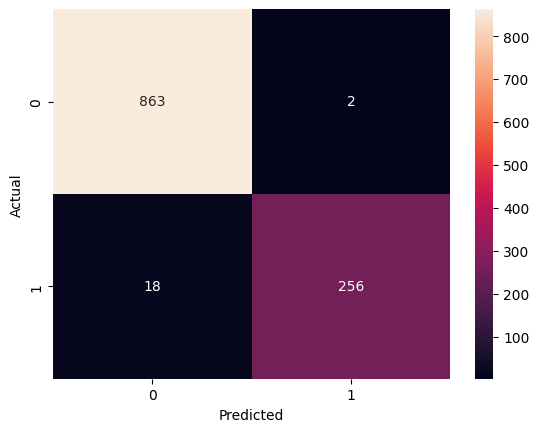

In [33]:
cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [34]:
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       865
           1       0.99      0.93      0.96       274

    accuracy                           0.98      1139
   macro avg       0.99      0.97      0.98      1139
weighted avg       0.98      0.98      0.98      1139



In [35]:
svm =SVC(kernel='linear',random_state=42)
svm.fit(x_train_vectorized,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [36]:
y_pred_svm=svm.predict(x_test_vectorized)

In [37]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)
precision_svm = precision_score(y_test, y_pred_svm)
print("SVM Precision:", precision_svm)
recall_svm = recall_score(y_test, y_pred_svm)
print("SVM Recall:", recall_svm)
f1_svm = f1_score(y_test, y_pred_svm)
print("SVM F1-score:", f1_svm)



SVM Accuracy: 0.9964881474978051
SVM Precision: 0.9963235294117647
SVM Recall: 0.9890510948905109
SVM F1-score: 0.9926739926739927


In [38]:
print(confusion_matrix(y_test, y_pred_svm))

[[864   1]
 [  3 271]]


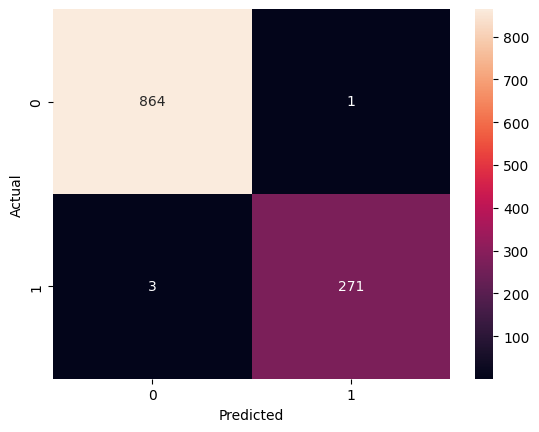

In [39]:
cm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [40]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       865
           1       1.00      0.99      0.99       274

    accuracy                           1.00      1139
   macro avg       1.00      0.99      1.00      1139
weighted avg       1.00      1.00      1.00      1139



In [41]:
nb=MultinomialNB()
nb.fit(x_train_vectorized,y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [42]:
y_pred_nb=nb.predict(x_test_vectorized)

In [43]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Naive Bayes Accuracy:", accuracy_nb)
precision_nb = precision_score(y_test, y_pred_nb)
print("Naive Bayes Precision:", precision_nb)
recall_nb = recall_score(y_test, y_pred_nb)
print("Naive Bayes Recall:", recall_nb)
f1_nb = f1_score(y_test, y_pred_nb)
print("Naive Bayes F1-score:", f1_nb)

Naive Bayes Accuracy: 0.9043020193151887
Naive Bayes Precision: 1.0
Naive Bayes Recall: 0.6021897810218978
Naive Bayes F1-score: 0.7517084282460137


In [44]:
print(confusion_matrix(y_test, y_pred_nb))

[[865   0]
 [109 165]]


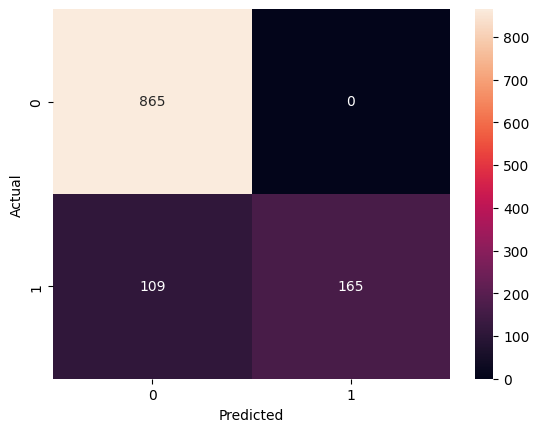

In [45]:
cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [46]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94       865
           1       1.00      0.60      0.75       274

    accuracy                           0.90      1139
   macro avg       0.94      0.80      0.85      1139
weighted avg       0.92      0.90      0.90      1139



In [47]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM", "Naive Bayes"],
    "Accuracy": [accuracy_log, accuracy_svm, accuracy_nb],
    "Precision": [precision_log, precision_svm, precision_nb],
    "Recall": [recall_log, recall_svm, recall_nb],
    "F1-score": [f1_log, f1_svm, f1_nb]
})

comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.982441,0.992248,0.934307,0.962406
1,SVM,0.996488,0.996324,0.989051,0.992674
2,Naive Bayes,0.904302,1.000000,0.602190,0.751708


In [ ]:
log_r_pipeline=Pipeline([
    ('vectorizer',
     TfidfVectorizer()),
     ('classifier',
      LogisticRegression(max_iter=1000,random_state=42))
])

param_grid={
    'vectorizer__ngram_range':[
    (1,1),
    (1,2)
]
     ,
     'vectorizer__max_df':[
         0.8,
         
     ],
     'vectorizer__min_df':
     [
        5
     ],
      'classifier__C':[
          0.1,
          1,
          10
      ]
       
}
grid_search=GridSearchCV(
    log_r_pipeline,

    param_grid,

    cv=3,

    scoring='accuracy',

    verbose=2
)
grid_search.fit(x_train,y_train)



print(grid_search.best_params_)
print(grid_search.best_score_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END classifier__C=0.1, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 1); total time=   0.8s
[CV] END classifier__C=0.1, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 1); total time=   0.7s
[CV] END classifier__C=0.1, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 1); total time=   0.7s
[CV] END classifier__C=0.1, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 2); total time=   2.8s
[CV] END classifier__C=0.1, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 2); total time=   2.7s
[CV] END classifier__C=0.1, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 2); total time=   2.7s
[CV] END classifier__C=0.1, vectorizer__max_df=0.8, vectorizer__min_df=5, vectorizer__ngram_range=(1, 1); total time=   0.7s
[CV] END classifier__C=0.1, vectorizer__max_df=0.8, vectorizer__

In [49]:
svm_pipeline=Pipeline([
    ('vectorizer',
     TfidfVectorizer()),
     ('classifier',
      SVC())
])

param_grid={
    'vectorizer__ngram_range':[
    (1,1),
    (1,2)
]
     ,
     'vectorizer__max_df':[
         0.8,
         1.0
     ],
     'vectorizer__min_df':
     [
        1,5
     ],
      'classifier__C':[
          0.1,
          1,
          10
      ],
      'classifier__kernel':[
          'linear',
          'rbf'
      ]
       
}
grid_search=GridSearchCV(
    svm_pipeline,

    param_grid,

    cv=3,

    scoring='accuracy',

    verbose=2
)
grid_search.fit(x_train,y_train)



print(grid_search.best_params_)
print(grid_search.best_score_)


Fitting 3 folds for each of 48 candidates, totalling 144 fits
[CV] END classifier__C=0.1, classifier__kernel=linear, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 1); total time=   6.3s
[CV] END classifier__C=0.1, classifier__kernel=linear, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 1); total time=   5.8s
[CV] END classifier__C=0.1, classifier__kernel=linear, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 1); total time=   5.8s
[CV] END classifier__C=0.1, classifier__kernel=linear, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 2); total time=  14.0s
[CV] END classifier__C=0.1, classifier__kernel=linear, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 2); total time=  16.3s
[CV] END classifier__C=0.1, classifier__kernel=linear, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 2); total time=  17.1s
[CV] END classifier__C=0.1

In [50]:
nb_pipeline = Pipeline([

    ('vectorizer',
     TfidfVectorizer()),

    ('classifier',
     MultinomialNB())
])


param_grid = {

    'vectorizer__ngram_range': [
        (1,1),
        (1,2)
    ],

    'vectorizer__max_df': [
        0.8,
        1.0
    ],

    'vectorizer__min_df': [
        1,
        5
    ],

    'classifier__alpha': [0.1,
        1.0,
        5.0
    ]
}


grid_search = GridSearchCV(

    nb_pipeline,

    param_grid,

    cv=3,

    scoring='accuracy',

    verbose=2
)

grid_search.fit(x_train, y_train) 
print(grid_search.best_params_)

print(grid_search.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END classifier__alpha=0.1, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 1); total time=   0.9s
[CV] END classifier__alpha=0.1, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 1); total time=   0.9s
[CV] END classifier__alpha=0.1, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 1); total time=   1.1s
[CV] END classifier__alpha=0.1, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 2); total time=   2.7s
[CV] END classifier__alpha=0.1, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 2); total time=   2.8s
[CV] END classifier__alpha=0.1, vectorizer__max_df=0.8, vectorizer__min_df=1, vectorizer__ngram_range=(1, 2); total time=   2.5s
[CV] END classifier__alpha=0.1, vectorizer__max_df=0.8, vectorizer__min_df=5, vectorizer__ngram_range=(1, 1); total time=   0.7s
[CV] END classifier__alpha=0.1, vect

In [52]:
message = ["Win money now"]

message_vectorized = vectorizer.transform(message)

prediction = log_r.predict(message_vectorized)

if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Spam


In [ ]:
import pickle

pickle.dump(log_r, open('spam_model.pkl', 'wb'))

pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))